In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [2]:
# ── reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# ── model (identical to baseline) ────────────────────────────────────────────
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super(AblationMLP, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, 1024)
        self.bn1 = nn.BatchNorm1d(1024) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc4 = nn.Linear(256, 10)

        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:   x = self.dropout1(x)

        x = self.fc2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:   x = self.dropout2(x)

        x = self.fc3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:   x = self.dropout3(x)

        x = self.fc4(x)
        return x

    def get_linear_weights(self):
        """Return all weight tensors from linear layers (flattened)."""
        return [self.fc1.weight, self.fc2.weight, self.fc3.weight, self.fc4.weight]

    def get_all_weights_flat(self):
        """Return a single flat numpy array of all linear-layer weights."""
        return torch.cat([w.data.view(-1) for w in self.get_linear_weights()]).cpu().numpy()

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training set size : {len(train_dataset)}")
print(f"Test set size     : {len(test_dataset)}")

100%|██████████| 170M/170M [03:57<00:00, 719kB/s]


Training set size : 50000
Test set size     : 10000


In [7]:
# ── helpers ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

MAX_EPOCHS    = 20
LEARNING_RATE = 0.01
L1_LAMBDA     = 1e-4
L2_WEIGHT_DECAY = 1e-3  # 10x stronger



def l1_penalty(model: nn.Module) -> torch.Tensor:
    """Sum of absolute values of all linear-layer weights."""
    return sum(w.abs().sum() for w in model.get_linear_weights())


def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


def train_one_run(label, use_l1=False, use_l2=False, use_adam=False):
    """
    Train a fresh model.
    - L2 is implemented via weight_decay in the optimizer (standard, efficient).
    - L1 is implemented by adding the penalty to the loss before backward().
    Returns dict with all tracked metrics + initial/final weight snapshots.
    """
    print(f"\n{'='*60}")
    print(f"  Training: {label}")
    print(f"{'='*60}")

    torch.manual_seed(42)  # seed BEFORE model creation
    torch.cuda.manual_seed(42)
    model = AblationMLP(use_dropout=False, use_batchnorm=False).to(device)
    wd = L2_WEIGHT_DECAY if use_l2 else 0.0
    if use_l2 and use_adam:
        optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=L2_WEIGHT_DECAY)
    else:
        wd = L2_WEIGHT_DECAY if use_l2 else 0.0
        optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=wd)
    loss_fn   = nn.CrossEntropyLoss()

    # ── capture initial weights ──
    initial_weights = model.get_all_weights_flat().copy()

    train_losses, train_accs, test_accs, l1_norms, l2_norms = [], [], [], [], []

    for epoch in range(MAX_EPOCHS):
        model.train()
        epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs  = model(images)
            loss     = loss_fn(outputs, labels)

            if use_l1:
                loss = loss + L1_LAMBDA * l1_penalty(model)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss  = epoch_loss / len(train_loader)
        train_acc = evaluate(model, train_loader)
        test_acc  = evaluate(model, test_loader)

        # weight-norm statistics (computed on CPU, no grad)
        with torch.no_grad():
            weights_cat = torch.cat([w.data.view(-1) for w in model.get_linear_weights()])
            l1_norms.append(weights_cat.abs().sum().item())
            l2_norms.append(weights_cat.pow(2).sum().sqrt().item())

        train_losses.append(avg_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"  Epoch {epoch+1:2d}/{MAX_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
              f"L1‑norm: {l1_norms[-1]:.1f} | L2‑norm: {l2_norms[-1]:.1f}")

    final_weights = model.get_all_weights_flat().copy()

    print(f"\n  Final Train Acc  : {train_accs[-1]:.2f}%")
    print(f"  Final Test Acc   : {test_accs[-1]:.2f}%")
    print(f"  Generalization Gap: {train_accs[-1] - test_accs[-1]:.2f}%")

    return {
        "label":           label,
        "train_losses":    train_losses,
        "train_accs":      train_accs,
        "test_accs":       test_accs,
        "l1_norms":        l1_norms,
        "l2_norms":        l2_norms,
        "initial_weights": initial_weights,
        "final_weights":   final_weights,
    }



Device: cuda


In [10]:
results_baseline = train_one_run("Baseline (No Regularization)", use_l1=False, use_l2=False)



  Training: Baseline (No Regularization)
  Epoch  1/20 | Loss: 2.1246 | Train: 31.27% | Test: 31.45% | L1‑norm: 39597.6 | L2‑norm: 24.6
  Epoch  2/20 | Loss: 1.8308 | Train: 38.74% | Test: 39.03% | L1‑norm: 39666.6 | L2‑norm: 24.6
  Epoch  3/20 | Loss: 1.6846 | Train: 42.64% | Test: 42.76% | L1‑norm: 39725.8 | L2‑norm: 24.7
  Epoch  4/20 | Loss: 1.5928 | Train: 45.36% | Test: 45.37% | L1‑norm: 39779.6 | L2‑norm: 24.8
  Epoch  5/20 | Loss: 1.5210 | Train: 48.20% | Test: 47.46% | L1‑norm: 39832.2 | L2‑norm: 24.8
  Epoch  6/20 | Loss: 1.4585 | Train: 49.58% | Test: 47.82% | L1‑norm: 39886.2 | L2‑norm: 24.9
  Epoch  7/20 | Loss: 1.4026 | Train: 52.54% | Test: 50.38% | L1‑norm: 39941.4 | L2‑norm: 24.9
  Epoch  8/20 | Loss: 1.3523 | Train: 53.70% | Test: 50.51% | L1‑norm: 39998.1 | L2‑norm: 25.0
  Epoch  9/20 | Loss: 1.3053 | Train: 56.19% | Test: 51.86% | L1‑norm: 40055.8 | L2‑norm: 25.1
  Epoch 10/20 | Loss: 1.2623 | Train: 57.23% | Test: 51.94% | L1‑norm: 40117.2 | L2‑norm: 25.1
  Epoch 

In [11]:
results_l1 = train_one_run("L1 Regularization", use_l1=True, use_l2=False)


  Training: L1 Regularization
  Epoch  1/20 | Loss: 6.0117 | Train: 31.04% | Test: 31.15% | L1‑norm: 38129.9 | L2‑norm: 23.9
  Epoch  2/20 | Loss: 5.5875 | Train: 38.18% | Test: 38.60% | L1‑norm: 36766.2 | L2‑norm: 23.4
  Epoch  3/20 | Loss: 5.3102 | Train: 41.95% | Test: 42.01% | L1‑norm: 35425.4 | L2‑norm: 22.9
  Epoch  4/20 | Loss: 5.0888 | Train: 44.49% | Test: 44.50% | L1‑norm: 34110.0 | L2‑norm: 22.3
  Epoch  5/20 | Loss: 4.8921 | Train: 47.00% | Test: 46.58% | L1‑norm: 32826.2 | L2‑norm: 21.8
  Epoch  6/20 | Loss: 4.7079 | Train: 48.26% | Test: 47.06% | L1‑norm: 31577.6 | L2‑norm: 21.3
  Epoch  7/20 | Loss: 4.5340 | Train: 50.95% | Test: 49.38% | L1‑norm: 30361.1 | L2‑norm: 20.8
  Epoch  8/20 | Loss: 4.3693 | Train: 51.93% | Test: 49.86% | L1‑norm: 29178.5 | L2‑norm: 20.3
  Epoch  9/20 | Loss: 4.2124 | Train: 54.21% | Test: 51.55% | L1‑norm: 28029.8 | L2‑norm: 19.9
  Epoch 10/20 | Loss: 4.0639 | Train: 55.02% | Test: 51.67% | L1‑norm: 26916.0 | L2‑norm: 19.4
  Epoch 11/20 | Los

In [12]:
results_l2_sgd = train_one_run("L2 Regularization (SGD)", use_l1=False, use_l2=True, use_adam=False)


  Training: L2 Regularization (SGD)
  Epoch  1/20 | Loss: 2.1256 | Train: 31.21% | Test: 31.43% | L1‑norm: 39443.2 | L2‑norm: 24.5
  Epoch  2/20 | Loss: 1.8335 | Train: 38.62% | Test: 38.91% | L1‑norm: 39359.0 | L2‑norm: 24.4
  Epoch  3/20 | Loss: 1.6882 | Train: 42.50% | Test: 42.53% | L1‑norm: 39265.8 | L2‑norm: 24.4
  Epoch  4/20 | Loss: 1.5972 | Train: 45.18% | Test: 45.14% | L1‑norm: 39168.0 | L2‑norm: 24.4
  Epoch  5/20 | Loss: 1.5265 | Train: 47.91% | Test: 47.17% | L1‑norm: 39069.7 | L2‑norm: 24.3
  Epoch  6/20 | Loss: 1.4649 | Train: 49.32% | Test: 47.70% | L1‑norm: 38973.7 | L2‑norm: 24.3
  Epoch  7/20 | Loss: 1.4101 | Train: 52.16% | Test: 50.06% | L1‑norm: 38879.1 | L2‑norm: 24.3
  Epoch  8/20 | Loss: 1.3610 | Train: 53.35% | Test: 50.27% | L1‑norm: 38787.1 | L2‑norm: 24.3
  Epoch  9/20 | Loss: 1.3150 | Train: 55.79% | Test: 51.70% | L1‑norm: 38696.5 | L2‑norm: 24.2
  Epoch 10/20 | Loss: 1.2732 | Train: 56.76% | Test: 52.00% | L1‑norm: 38610.3 | L2‑norm: 24.2
  Epoch 11/20

In [15]:
all_results = [results_baseline, results_l1, results_l2_sgd]
epochs      = range(1, MAX_EPOCHS + 1)
COLORS      = {"Baseline (No Regularization)": "#e74c3c",
               "L1 Regularization":            "#2ecc71",
               "L2 Regularization (SGD)":      "#3498db"}

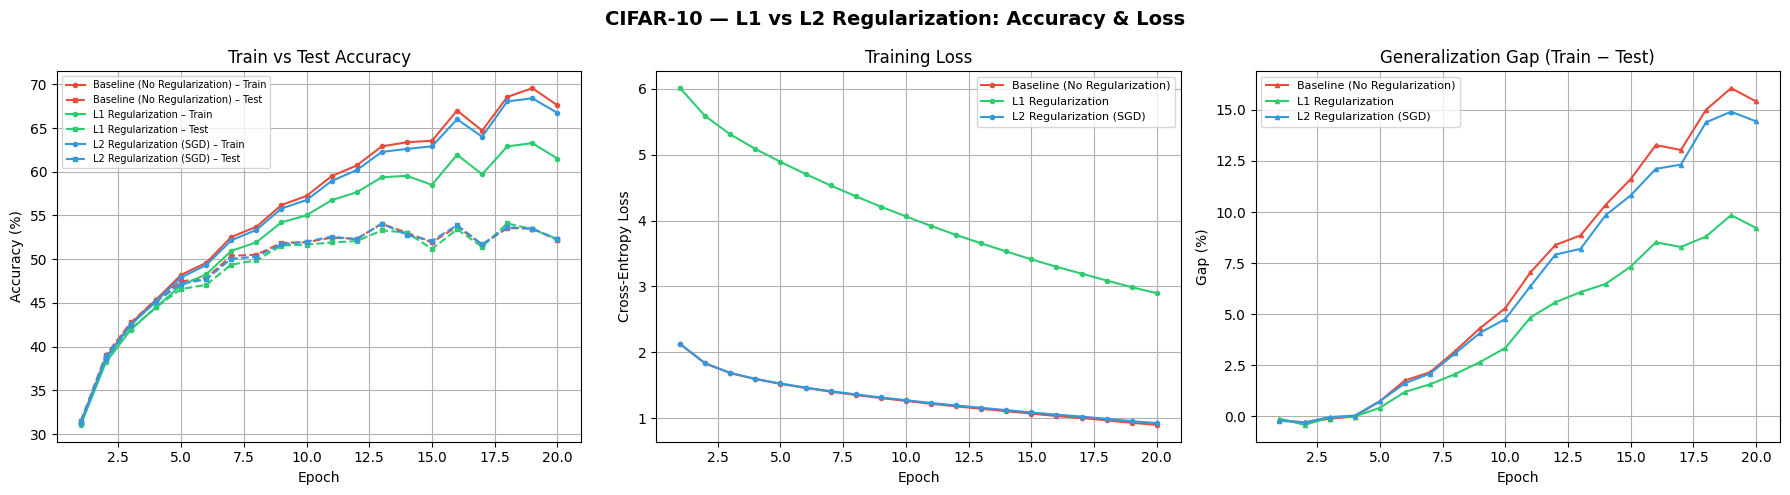

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 1 — Accuracy & Loss curves  (mirrors baseline plot style)
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("CIFAR-10 — L1 vs L2 Regularization: Accuracy & Loss", fontsize=14, fontweight='bold')

# train/test accuracy per run
for r in all_results:
    c = COLORS[r["label"]]
    axes1[0].plot(epochs, r["train_accs"], linestyle='-',  marker='o', color=c,
                  label=f'{r["label"]} – Train', linewidth=1.5, markersize=3)
    axes1[0].plot(epochs, r["test_accs"],  linestyle='--', marker='s', color=c,
                  label=f'{r["label"]} – Test',  linewidth=1.5, markersize=3)
axes1[0].set_title("Train vs Test Accuracy")
axes1[0].set_xlabel("Epoch"); axes1[0].set_ylabel("Accuracy (%)")
axes1[0].legend(fontsize=7); axes1[0].grid(True)

# training loss
for r in all_results:
    axes1[1].plot(epochs, r["train_losses"], marker='o', color=COLORS[r["label"]],
                  label=r["label"], linewidth=1.5, markersize=3)
axes1[1].set_title("Training Loss")
axes1[1].set_xlabel("Epoch"); axes1[1].set_ylabel("Cross-Entropy Loss")
axes1[1].legend(fontsize=8); axes1[1].grid(True)

# generalization gap
for r in all_results:
    gap = [tr - te for tr, te in zip(r["train_accs"], r["test_accs"])]
    axes1[2].plot(epochs, gap, marker='^', color=COLORS[r["label"]],
                  label=r["label"], linewidth=1.5, markersize=3)
axes1[2].set_title("Generalization Gap (Train − Test)")
axes1[2].set_xlabel("Epoch"); axes1[2].set_ylabel("Gap (%)")
axes1[2].legend(fontsize=8); axes1[2].grid(True)

plt.tight_layout()
plt.savefig("fig1_accuracy_loss.png", dpi=150, bbox_inches='tight')
plt.show()

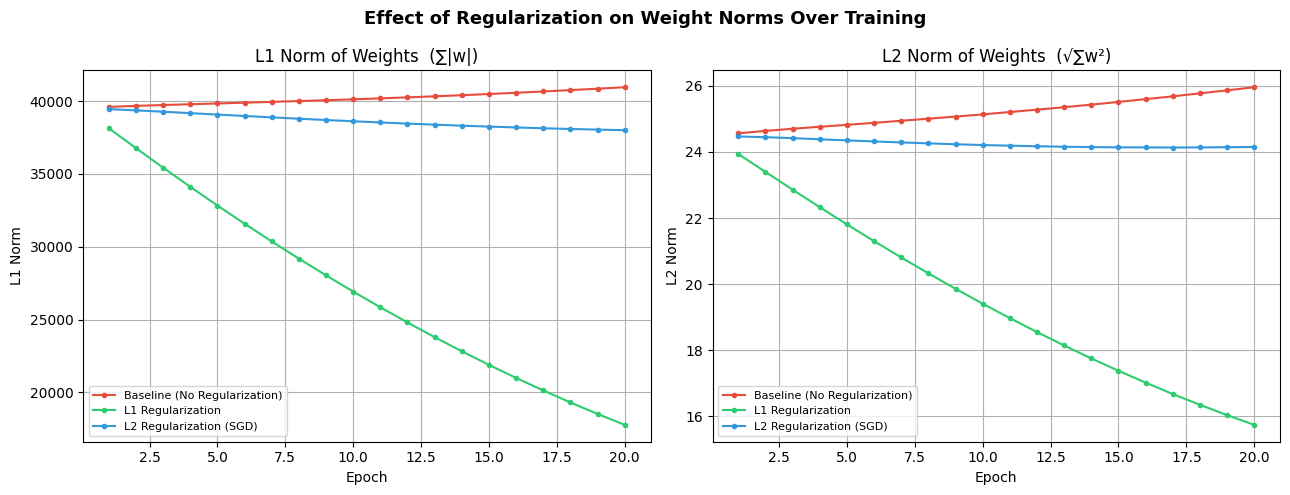

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 2 — Weight-norm evolution over training
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Effect of Regularization on Weight Norms Over Training", fontsize=13, fontweight='bold')

for r in all_results:
    c = COLORS[r["label"]]
    axes2[0].plot(epochs, r["l1_norms"], marker='o', color=c,
                  label=r["label"], linewidth=1.5, markersize=3)
    axes2[1].plot(epochs, r["l2_norms"], marker='o', color=c,
                  label=r["label"], linewidth=1.5, markersize=3)

axes2[0].set_title("L1 Norm of Weights  (∑|w|)")
axes2[0].set_xlabel("Epoch"); axes2[0].set_ylabel("L1 Norm")
axes2[0].legend(fontsize=8); axes2[0].grid(True)

axes2[1].set_title("L2 Norm of Weights  (√∑w²)")
axes2[1].set_xlabel("Epoch"); axes2[1].set_ylabel("L2 Norm")
axes2[1].legend(fontsize=8); axes2[1].grid(True)

plt.tight_layout()
plt.savefig("fig2_weight_norms.png", dpi=150, bbox_inches='tight')
plt.show()

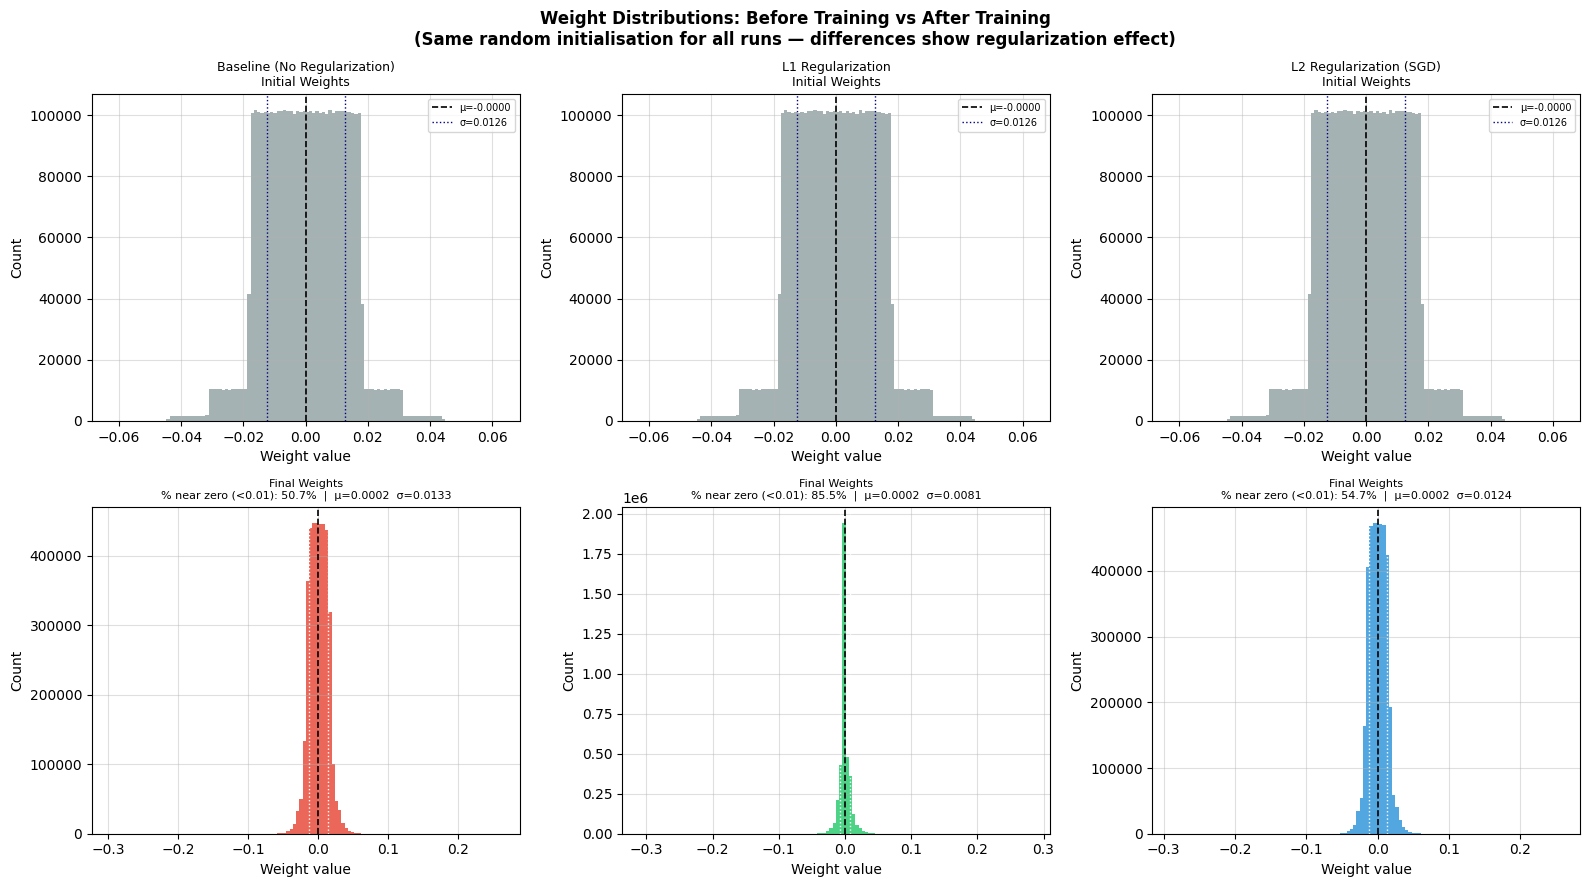

In [18]:
#  Figure 3 — Weight distribution histograms: initial vs final
#  Shows the key difference between L1 (sparsity / spike at 0) and L2 (shrinkage)
# ─────────────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 9))
fig3.suptitle("Weight Distributions: Before Training vs After Training\n"
              "(Same random initialisation for all runs — differences show regularization effect)",
              fontsize=12, fontweight='bold')

BINS = 120

for col, r in enumerate(all_results):
    c = COLORS[r["label"]]

    # ── initial (same for all, but shown per column for visual clarity) ──
    axes3[0, col].hist(r["initial_weights"], bins=BINS, color='#95a5a6', edgecolor='none', alpha=0.85)
    axes3[0, col].set_title(f"{r['label']}\nInitial Weights", fontsize=9)
    axes3[0, col].set_xlabel("Weight value"); axes3[0, col].set_ylabel("Count")

    # stats annotation
    iw = r["initial_weights"]
    axes3[0, col].axvline(iw.mean(), color='black', linestyle='--', linewidth=1.2, label=f'μ={iw.mean():.4f}')
    axes3[0, col].axvline(iw.mean() + iw.std(), color='navy', linestyle=':', linewidth=1, label=f'σ={iw.std():.4f}')
    axes3[0, col].axvline(iw.mean() - iw.std(), color='navy', linestyle=':', linewidth=1)
    axes3[0, col].legend(fontsize=7)
    axes3[0, col].grid(True, alpha=0.4)

    # ── final ──
    fw = r["final_weights"]
    axes3[1, col].hist(fw, bins=BINS, color=c, edgecolor='none', alpha=0.85)
    axes3[1, col].set_title(f"Final Weights\n"
                             f"% near zero (<0.01): {100*(np.abs(fw)<0.01).mean():.1f}%  |  "
                             f"μ={fw.mean():.4f}  σ={fw.std():.4f}", fontsize=8)
    axes3[1, col].set_xlabel("Weight value"); axes3[1, col].set_ylabel("Count")
    axes3[1, col].axvline(fw.mean(), color='black', linestyle='--', linewidth=1.2)
    axes3[1, col].axvline(fw.mean() + fw.std(), color='white', linestyle=':', linewidth=1)
    axes3[1, col].axvline(fw.mean() - fw.std(), color='white', linestyle=':', linewidth=1)
    axes3[1, col].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig3_weight_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

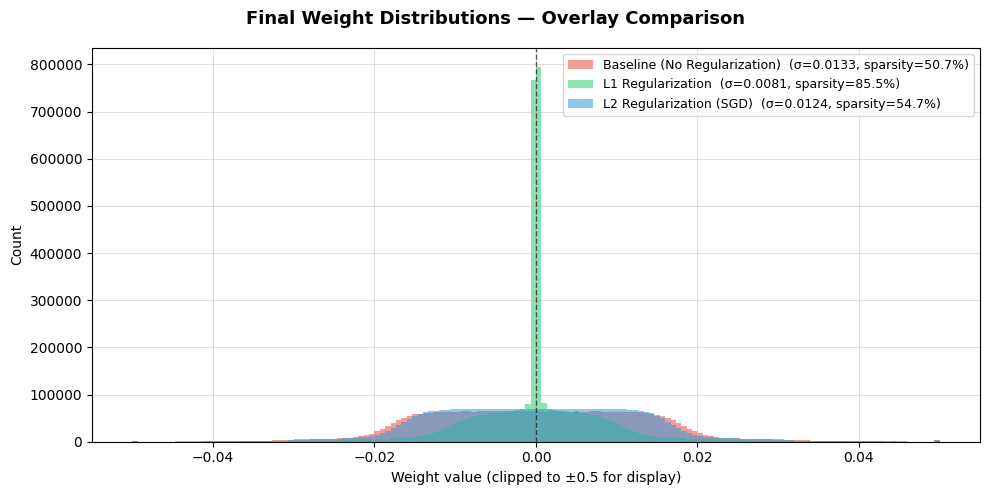

In [22]:
#  Figure 4 — Side-by-side final weight distributions (overlay)
#  Clean single plot to highlight L1 sparsity vs L2 shrinkage
# ─────────────────────────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 5))
fig4.suptitle("Final Weight Distributions — Overlay Comparison", fontsize=13, fontweight='bold')

for r in all_results:
    fw = r["final_weights"]
    # clip extreme tails for readability
    clipped = np.clip(fw, -0.05, 0.05)
    ax4.hist(clipped, bins=150, alpha=0.55, color=COLORS[r["label"]],
             label=f'{r["label"]}  (σ={fw.std():.4f}, '
                   f'sparsity={100*(np.abs(fw)<0.01).mean():.1f}%)',
             edgecolor='none')

ax4.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax4.set_xlabel("Weight value (clipped to ±0.5 for display)")
ax4.set_ylabel("Count")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig4_weight_overlay.png", dpi=150, bbox_inches='tight')
plt.show()



In [21]:
#  Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*75)
print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'L1-norm':>10} {'L2-norm':>10}")
print("-"*75)
for r in all_results:
    fw = r["final_weights"]
    print(f"{r['label']:<30} "
          f"{r['train_accs'][-1]:>9.2f}% "
          f"{r['test_accs'][-1]:>9.2f}% "
          f"{r['train_accs'][-1]-r['test_accs'][-1]:>7.2f}% "
          f"{r['l1_norms'][-1]:>10.1f} "
          f"{r['l2_norms'][-1]:>10.1f}")
print("="*75)
print(f"\nL1 sparsity (|w|<0.01): "
      f"Baseline {100*(np.abs(results_baseline['final_weights'])<0.01).mean():.1f}% | "
      f"L1 {100*(np.abs(results_l1['final_weights'])<0.01).mean():.1f}% | "
      f"L2 {100*(np.abs(results_l2_sgd['final_weights'])<0.01).mean():.1f}%")


Model                           Train Acc   Test Acc      Gap    L1-norm    L2-norm
---------------------------------------------------------------------------
Baseline (No Regularization)       67.60%     52.19%   15.41%    40948.5       26.0
L1 Regularization                  61.51%     52.29%    9.22%    17767.6       15.7
L2 Regularization (SGD)            66.73%     52.30%   14.43%    37997.4       24.2

L1 sparsity (|w|<0.01): Baseline 50.7% | L1 85.5% | L2 54.7%
